<a href="https://colab.research.google.com/github/poorvakale10/WasteClassificationProject/blob/main/WasteClassificationProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
PROJECT_PATH = '/content/drive/MyDrive/WasteClassificationProject'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"Created folder at {PROJECT_PATH}")
else:
    print(f"Folder already exists at {PROJECT_PATH}")

Folder already exists at /content/drive/MyDrive/WasteClassificationProject


In [3]:
!cp kaggle.json /content/drive/MyDrive/WasteClassificationProject/
print("File successfully saved to Drive!")

cp: cannot stat 'kaggle.json': No such file or directory
File successfully saved to Drive!


In [4]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/WasteClassificationProject/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle is now linked to your Google Drive!")

Kaggle is now linked to your Google Drive!


In [5]:
!kaggle datasets download -d mostafaabla/garbage-classification
!unzip -o -q garbage-classification.zip -d dataset

print("Dataset is ready to go!")

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset is ready to go!


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = 'dataset/garbage_classification'

# Setup Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2 # 20% for testing during training
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# Load the brain (pre-trained weights)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras import callbacks

# Stop training if the model stops getting better
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Starting training...
Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 272s 649ms/step - accuracy: 0.8309 - loss: 0.5434 - val_accuracy: 0.8403 - val_loss: 0.4934
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 224s 577ms/step - accuracy: 0.8888 - loss: 0.3458 - val_accuracy: 0.8768 - val_loss: 0.3705
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 222s 572ms/step - accuracy: 0.9034 - loss: 0.3060 - val_accuracy: 0.8774 - val_loss: 0.3656
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 219s 564ms/step - accuracy: 0.9044 - loss: 0.2895 - val_accuracy: 0.8732 - val_loss: 0.3812
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 570ms/step - accuracy: 0.9103 - loss: 0.2611 - val_accuracy: 0.8826 - val_loss: 0.3427
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 569ms/step - accuracy: 0.9182 - loss: 0.2479 - val_accuracy: 0.8881 - val_loss: 0.3222
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 219s 565ms/step - accuracy: 0.9246 - loss: 0.2264 - val_accuracy: 0.8768 - val_loss: 0.3800
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 570ms/step

In [8]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')
print("Model loaded successfully! You are ready to predict.")

Model loaded successfully! You are ready to predict.


Saving metalcan to metalcan (1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


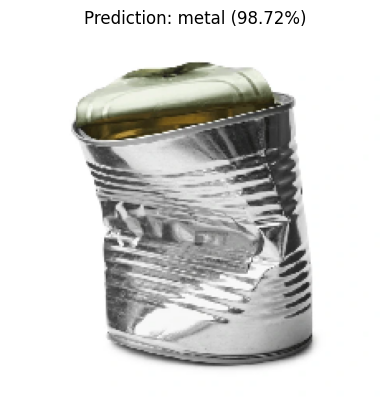

In [9]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
  # Load and predict
  img = image.load_img(fn, target_size=(224, 224))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  res = model.predict(img_array)
  class_idx = np.argmax(res)
  labels = list(train_generator.class_indices.keys())

  # Show result
  plt.imshow(img)
  plt.title(f"Prediction: {labels[class_idx]} ({100*np.max(res):.2f}%)")
  plt.axis('off')
  plt.show()

In [10]:
model.save('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')
print("Model is now safely stored in Google Drive")
from google.colab import files
files.download('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')


Model is now safely stored in Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
!pip install --upgrade gradio

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: cardboard (69.40%)


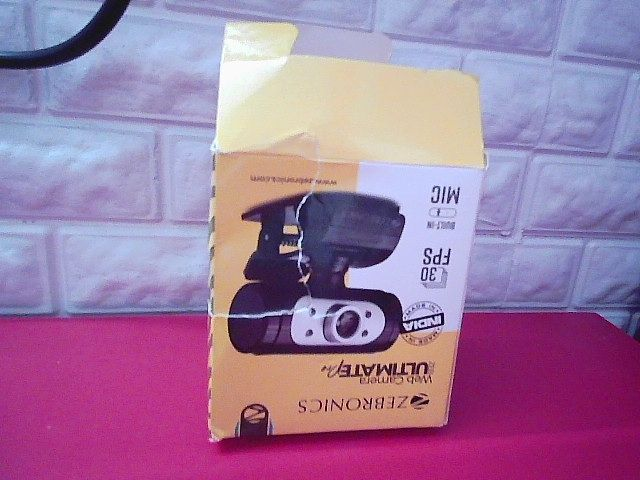

In [14]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model

# Load model
model = load_model('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')

classes = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

# Function to capture image from webcam
from google.colab import output
from IPython.display import display, Javascript
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = output.eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture image
image_path = take_photo()

# Predict
img = cv2.imread(image_path)
img_resized = cv2.resize(img, (224,224))
img_resized = img_resized / 255.0
img_resized = np.reshape(img_resized, (1,224,224,3))

prediction = model.predict(img_resized)
class_name = classes[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Prediction: {class_name} ({confidence*100:.2f}%)")
cv2_imshow(img)

In [18]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
import os
from tensorflow.keras.models import load_model

# Load model and define classes here to ensure they are available to predict_ui
try:
    model = model # Use existing model if defined
except NameError:
    # Fallback to load model if not already loaded (e.g., if running this cell alone)
    model = load_model('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')

# Define classes as a global variable as it's used by predict_ui and not directly linked to train_generator in this context
# Assuming train_generator.class_indices.keys() would give these in order, matching `classes` from oXT94_dwoQhm
labels = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


# Updated CSS for modern dark-themed glassmorphism
custom_css = """
body, .gradio-container {
    background-color: #0f172a !important;
    background-image: radial-gradient(circle at 10% 20%, rgba(56, 189, 248, 0.05) 0%, transparent 40%), radial-gradient(circle at 90% 80%, rgba(16, 185, 129, 0.05) 0%, transparent 40%) !important;
    color: #f8fafc;
    font-family: 'Inter', -apple-system, sans-serif !important;
}
#container {
    max-width: 1000px;
    margin: 0 auto;
    padding: 40px 20px;
}
.header {
    text-align: center;
    margin-bottom: 40px;
}
.header h1 {
    font-size: 38px !important;
    font-weight: 800 !important;
    background: linear-gradient(135deg, #38bdf8, #10b981);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom: 12px;
    letter-spacing: -0.5px;
}
.header p {
    color: #94a3b8 !important;
    font-size: 16px;
    font-weight: 500;
    letter-spacing: 0.5px;
}
.glass-panel {
    border-radius: 24px !important;
    border: 1px solid rgba(255, 255, 255, 0.08) !important;
    background: rgba(30, 41, 59, 0.6) !important;
    backdrop-filter: blur(16px) !important;
    -webkit-backdrop-filter: blur(16px) !important;
    padding: 30px !important;
    box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.5) !important;
}
.predict-btn {
    background: linear-gradient(135deg, #10b981, #059669) !important;
    color: #ffffff !important;
    border: none !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
    box-shadow: 0 4px 15px rgba(16, 185, 129, 0.3) !important;
    min-height: 48px !important;
}
.predict-btn:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 25px rgba(16, 185, 129, 0.4) !important;
}
.clear-btn {
    background: rgba(255, 255, 255, 0.05) !important;
    color: #e2e8f0 !important;
    border: 1px solid rgba(255, 255, 255, 0.1) !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
    min-height: 48px !important;
}
.clear-btn:hover {
    background: rgba(255, 255, 255, 0.1) !important;
}
.result-display {
    font-size: 28px;
    font-weight: 800;
    color: #f8fafc;
    background: rgba(16, 185, 129, 0.15);
    border: 1px solid rgba(16, 185, 129, 0.3);
    padding: 24px;
    border-radius: 16px;
    text-align: center;
    box-shadow: inset 0 2px 15px rgba(16, 185, 129, 0.05);
}
.result-display .confidence {
    display: block;
    font-size: 14px;
    font-weight: 600;
    color: #34d399;
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-top: 8px;
}
.section-title {
    color: #e2e8f0 !important;
    font-weight: 600 !important;
    font-size: 18px !important;
    margin-bottom: 16px !important;
    border-bottom: 1px solid rgba(255,255,255,0.1);
    padding-bottom: 12px;
}
"""

# The prediction logic stays the same
def predict_ui(upload_img, webcam_img): # Modified to accept two inputs
    img = None
    if upload_img is not None:
        img = upload_img
    elif webcam_img is not None:
        img = webcam_img

    if img is None: return "<div style='color:#64748b; text-align:center; padding:30px 0;'>Awaiting Image</div>", {}

    img_resized = img.resize((224, 224))
    img_array = image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    try:
        prediction = model.predict(img_array)[0]
        top_3_idx = np.argsort(prediction)[-3:][::-1]
        top_3_results = {labels[i]: float(prediction[i]) for i in top_3_idx}
        best_class = labels[top_3_idx[0]].upper().replace('-', ' ')
        conf = prediction[top_3_idx[0]] * 100
        result_html = f"<div class='result-display'>{best_class} <span class='confidence'>CONFIDENCE: {conf:.1f}%</span></div>"
    except NameError:
        result_html = "<div class='result-display'>MODEL OR LABELS NOT LOADED <span class='confidence'>ERROR</span></div>"
        top_3_results = {"Error": 1.0}

    return result_html, top_3_results

empty_state_html = "<div style='color:#64748b; text-align:center; padding: 40px 0; font-size: 15px; font-weight: 500; border: 1px dashed rgba(255,255,255,0.1); border-radius: 12px; mt-4'>System standby. Awaiting input...</div>"

with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="container"):
        # Header Section
        gr.HTML("""
            <div class='header'>
                <h1>Waste Classifier System</h1>
                <p>Intelligent Machine Vision for Recycling Infrastructure</p>
            </div>
        """)

        with gr.Row():
            # Left Column
            with gr.Column(elem_classes="glass-panel"):
                gr.Markdown("<div class='section-title'>Input Source</div>")
                with gr.Tabs(): # Use tabs for input selection
                    with gr.TabItem("Upload Image"):
                        upload_input_img = gr.Image(type="pil", label="Upload Material Image", elem_classes="image-input")
                    with gr.TabItem("Webcam"):
                        webcam_input_img = gr.Image(sources=["webcam"], type="pil", label="Capture Material Image") # Changed to gr.Image with sources=["webcam"]
                with gr.Row():
                    clear_btn = gr.Button("Reset", elem_classes="clear-btn")
                    submit_btn = gr.Button("Analyze Material", variant="primary", elem_classes="predict-btn")

            # Right Column
            with gr.Column(elem_classes="glass-panel"):
                gr.Markdown("<div class='section-title'>Analysis Diagnostics</div>")
                output_html = gr.HTML(empty_state_html)
                output_label = gr.Label(label="Probability Distribution", num_top_classes=3)


    # Logic
    submit_btn.click(fn=predict_ui, inputs=[upload_input_img, webcam_input_img], outputs=[output_html, output_label])
    # Clear button now clears both image inputs
    clear_btn.click(lambda: (None, None, empty_state_html, {}),
                    None, [upload_input_img, webcam_input_img, output_html, output_label])

# Launch!
if __name__ == "__main__":
    demo.launch(share=True, debug=True)

/tmp/ipykernel_10067/770827533.py:143: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7ac8e00416ba032d0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7ac8e00416ba032d0f.gradio.live
